# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

**Data exploration:**
Initial data exploration was conducted using SQL to analyze the schema of the provided datasets. This step was crucial to identify any data entry errors or structural discrepancies prior to the data cleaning phase.

In [2]:
-- Explore the data in the table
SELECT *
FROM 'da_fitly_account_info.csv'


,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,None
3,C10003,user10003@example.com,Michigan,Free,0,None
4,C10004,user10004@example.com,Texas,Enterprise,119,None
...,...,...,...,...,...,...
395,C10395,user10395@example.org,Arizona,Free,0,None
396,C10396,user10396@example.net,Vermont,Free,0,None
397,C10397,user10397@example.net,Vermont,Free,0,Y
398,C10398,user10398@example.net,Alabama,Enterprise,81,None


In [3]:
SELECT *
FROM 'da_fitly_customer_support.csv'


,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573+00:00,10125,chat,technical,11.48,1,None
1,2025-08-06 13:21:54.539551+00:00,10109,chat,account,1.01,0,None
2,2025-08-22 12:39:35.718663+00:00,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055+00:00,10268,phone,account,9.10,1,None
4,2025-07-25 00:24:38.945079+00:00,10041,phone,other,2.28,1,None
...,...,...,...,...,...,...,...
913,2025-06-05 23:09:46.282238+00:00,10225,chat,other,32.46,0,None
914,2025-08-19 11:03:30.765219+00:00,10081,chat,account,4.98,0,None
915,2025-08-07 13:17:13.090150+00:00,10373,chat,other,14.65,0,None
916,2025-07-06 11:28:27.421494+00:00,10148,phone,billing,18.35,1,None


In [4]:
SELECT *
FROM 'da_fitly_user_activity.csv'

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721+00:00,10118,watch_video
1,2025-09-08 08:15:05.264103+00:00,10220,watch_video
2,2025-11-14 06:28:35.207671+00:00,10009,share_workout
3,2025-08-20 16:53:38.682901+00:00,10227,read_article
4,2025-07-24 16:47:31.728422+00:00,10123,track_workout
...,...,...,...
440,2025-10-22 12:09:09.477660+00:00,10395,read_article
441,2025-09-22 18:28:07.618295+00:00,10264,watch_video
442,2025-07-28 14:52:16.311955+00:00,10241,track_workout
443,2025-11-27 13:38:32.371575+00:00,10340,track_workout


In [5]:
SELECT channel, COUNT(*) AS channel_count
FROM 'da_fitly_customer_support.csv'
GROUP BY channel

,channel,channel_count
0,-,39
1,chat,294
2,phone,287
3,email,298


In [6]:
-- Explore the data in the table
SELECT plan, COUNT(*)
FROM 'da_fitly_account_info.csv'
GROUP BY plan

,plan,count_star()
0,Enterprise,92
1,Basic,118
2,Pro,85
3,Free,105


In [7]:
SELECT churn_status, COUNT(*) AS count_churn
FROM 'da_fitly_account_info.csv'
GROUP BY churn_status
ORDER BY churn_status

,churn_status,count_churn
0,Y,114
1,None,286


In [8]:
SELECT event_type, COUNT(*)
FROM 'da_fitly_user_activity.csv'
GROUP BY event_type

,event_type,count_star()
0,share_workout,92
1,read_article,125
2,track_workout,108
3,watch_video,120


**Data Cleaning:**
Regarding the customer_support table, the Product Manager mentioned the possibility of duplicate tickets. Therefore, I investigated the ticket_time column to verify the data's integrity and confirm that there were no duplicated entries.

In [9]:
SELECT 
    ticket_time, 
    COUNT(*) AS cantidad_de_registros
FROM 
    'da_fitly_customer_support.csv'
GROUP BY 
    ticket_time
HAVING 
    COUNT(*) > 1
ORDER BY 
    cantidad_de_registros DESC;

,ticket_time,cantidad_de_registros


**Erasing Solicited Data:**
In the customer_support table, specifically in the comments column, there are several instances where users asked to delete their data. Removing these records was the first step I took, because processing this information could lead to legal problems for the company.

In [10]:
SELECT 
    comments, 
    user_id,  
    COUNT(*) AS cantidad
FROM 
    'da_fitly_customer_support.csv'
WHERE 
    comments IS NOT NULL
GROUP BY  
    comments, 
    user_id
ORDER BY  
    user_id;

,comments,user_id,cantidad
0,Request deletion of all records.,10018,1
1,Request full personal data deletion.,10020,1
2,Erase my data from your systems.,10029,1
3,Please delete all my personal data.,10032,1
4,Wipe all data you hold.,10038,1
5,Remove my personal records.,10065,1
6,Delete my information entirely.,10085,1
7,Request to remove my data.,10091,1
8,Wipe all data you hold.,10095,1
9,Requesting right to be forgotten.,10103,1


**Data Cleaning:**
First step: Delete all the data that the clients asked for with python.

In [11]:
usuarios_gdpr = df1[df1['comments'].notna()]['user_id'].unique()

print(f"Se encontraron {len(usuarios_gdpr)} usuarios para eliminar por GDPR.")

Se encontraron 43 usuarios para eliminar por GDPR.


Using the user_id to clean the other tables.

In [12]:
# Data cleaning
# Removing C from customers table
id_numerico = df['customer_id'].astype(str).str.replace('C', '').astype(int)
# Aplying the filter
df_account_clean = df[~id_numerico.isin(usuarios_gdpr)].copy()

# Cleaning the other tables
df_support_clean = df1[~df1['user_id'].isin(usuarios_gdpr)].copy()
df_activity_clean = df2[~df2['user_id'].isin(usuarios_gdpr)].copy()

# Confirmation
print(f"Filas en df_account_clean ahora: {len(df_account_clean)}")

Filas en df_account_clean ahora: 357


Exploring the data types to compare the customer_id with the other tables.

In [13]:
df_account_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 357 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      357 non-null    object
 1   email            357 non-null    object
 2   state            357 non-null    object
 3   plan             357 non-null    object
 4   plan_list_price  357 non-null    int64 
 5   churn_status     97 non-null     object
dtypes: int64(1), object(5)
memory usage: 19.5+ KB


**Data analysis:**
Our initial exploration reveals a churn rate of 27.2% across the platform. Establishing this metric is critical as we proceed to investigate the specific factors such as plan type and support experience that are driving these cancellations.

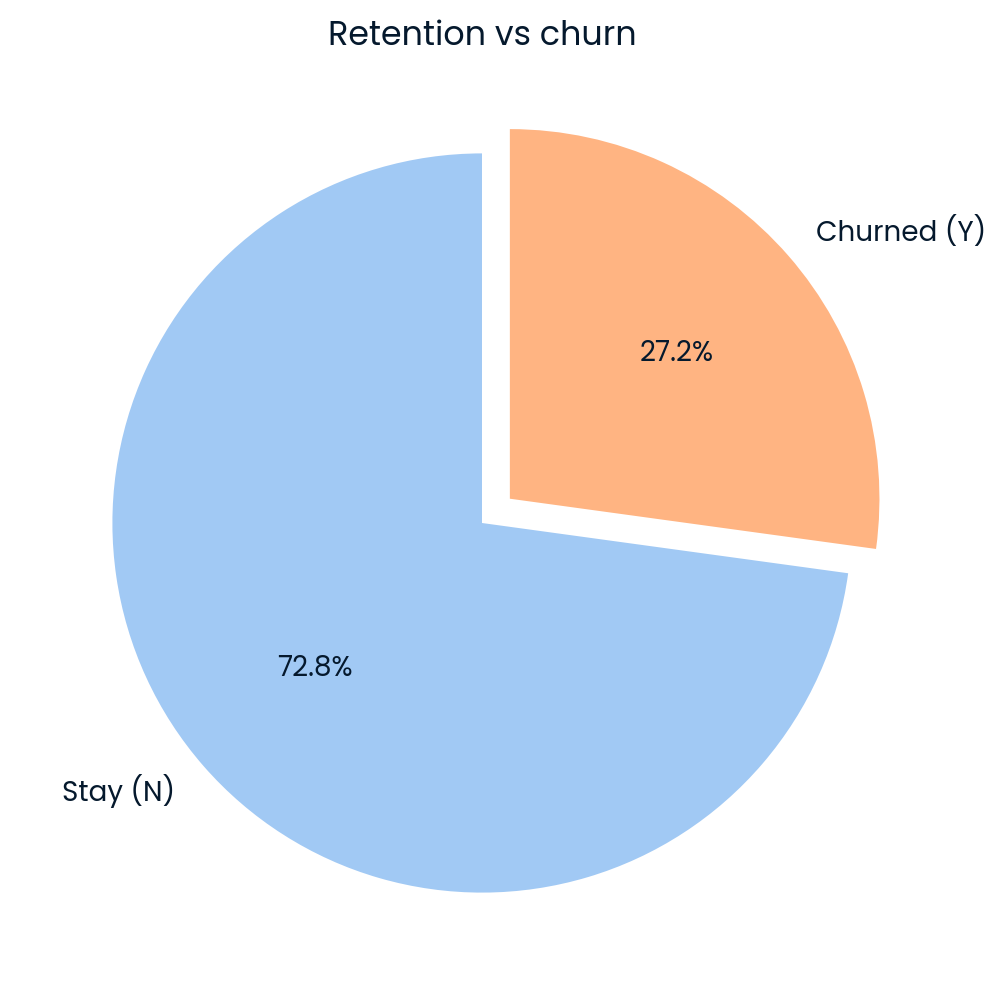

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df_account_clean['churn_status'] = df_account_clean['churn_status'].fillna('N')
churn_counts = df_account_clean['churn_status'].value_counts()
colores = sns.color_palette("pastel")

plt.figure(figsize=(6, 6)) 
plt.pie(
    churn_counts, 
    labels=['Stay (N)', 'Churned (Y)'], # Labels
    colors=colores, 
    autopct='%1.1f%%', 
    startangle=90, 
    explode=(0, 0.1) 
)

plt.title('Retention vs churn')

plt.show()

**Users by plan:**
Visualizing the account types through a countplot indicates that the "Basic" tier is the most popular plan among our users. Beyond this peak, the distribution remains largely uniform across the other subscription plans, suggesting a diverse customer portfolio.

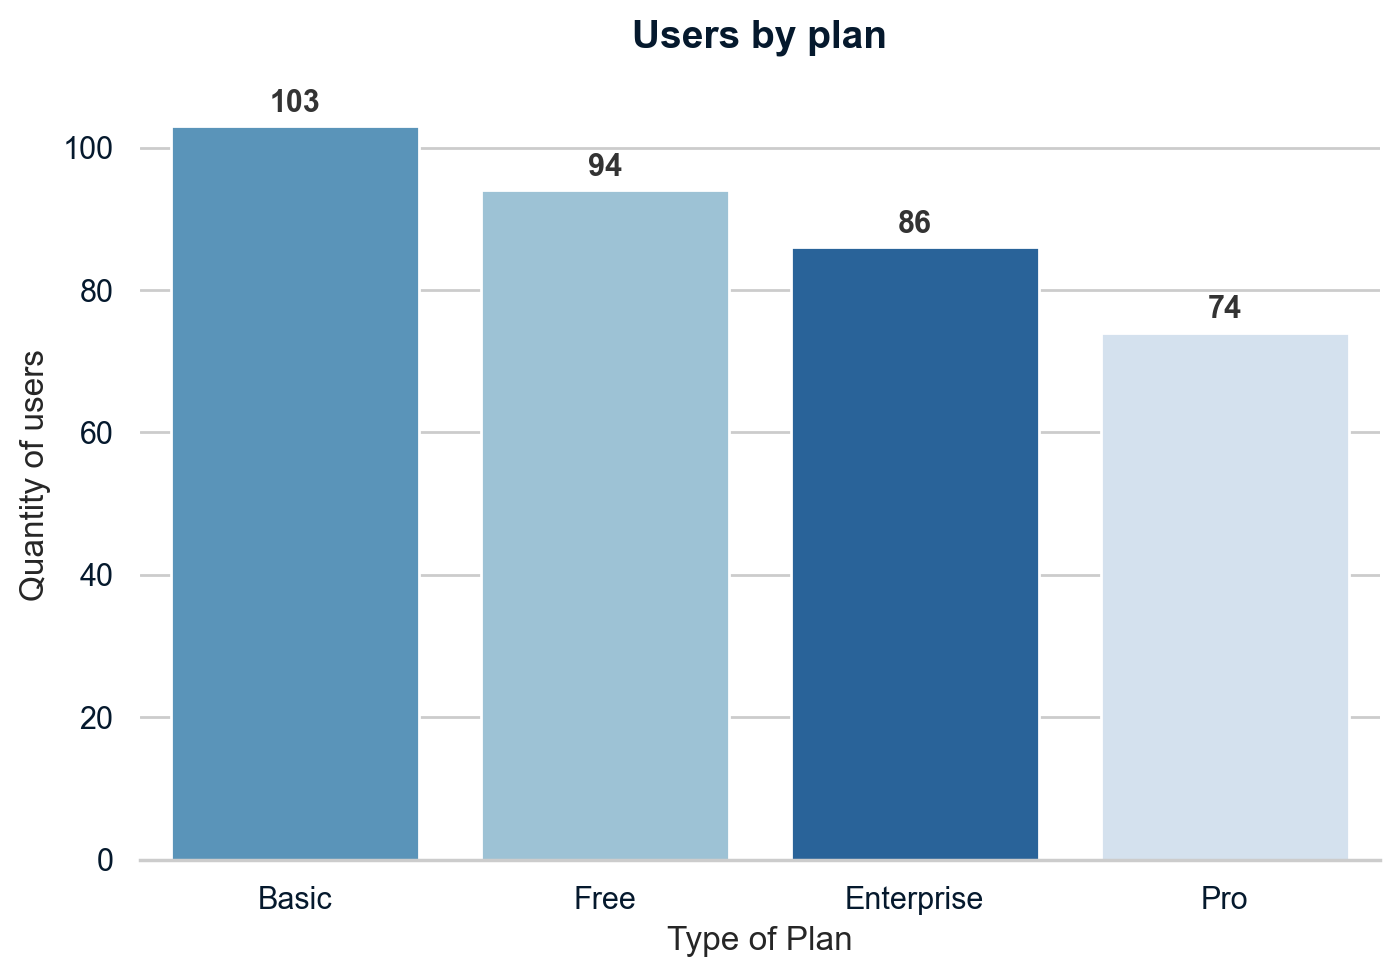

In [15]:
# Theme
sns.set_theme(style="whitegrid")

# Size
plt.figure(figsize=(8, 5))

# Order
orden_planes = df_account_clean['plan'].value_counts().index

# Graphic
ax = sns.countplot(
    x='plan', 
    data=df_account_clean, 
    order=orden_planes,       
    palette='Blues_r',        
    hue='plan',              
    legend=False              
)

# Numbers on the bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight='bold', color='#333333')
# ----------------------------

# Titles and labels
plt.title('Users by plan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Type of Plan', fontsize=12)
plt.ylabel('Quantity of users', fontsize=12)


sns.despine(left=True)

plt.show()

**Retention rate by Plan:**
To identify potential points of failure within our service, I analyzed the churn rate segmented by subscription tier. This approach allows us to understand exactly which customer profiles are at the highest risk of cancellation and require immediate attention.
The data indicates that the "Free" tier has the highest likelihood of churn. This elevated cancellation rate is likely driven by the absence of a financial sunk cost, making it frictionless for users to leave if they do not immediately engage with the platform.

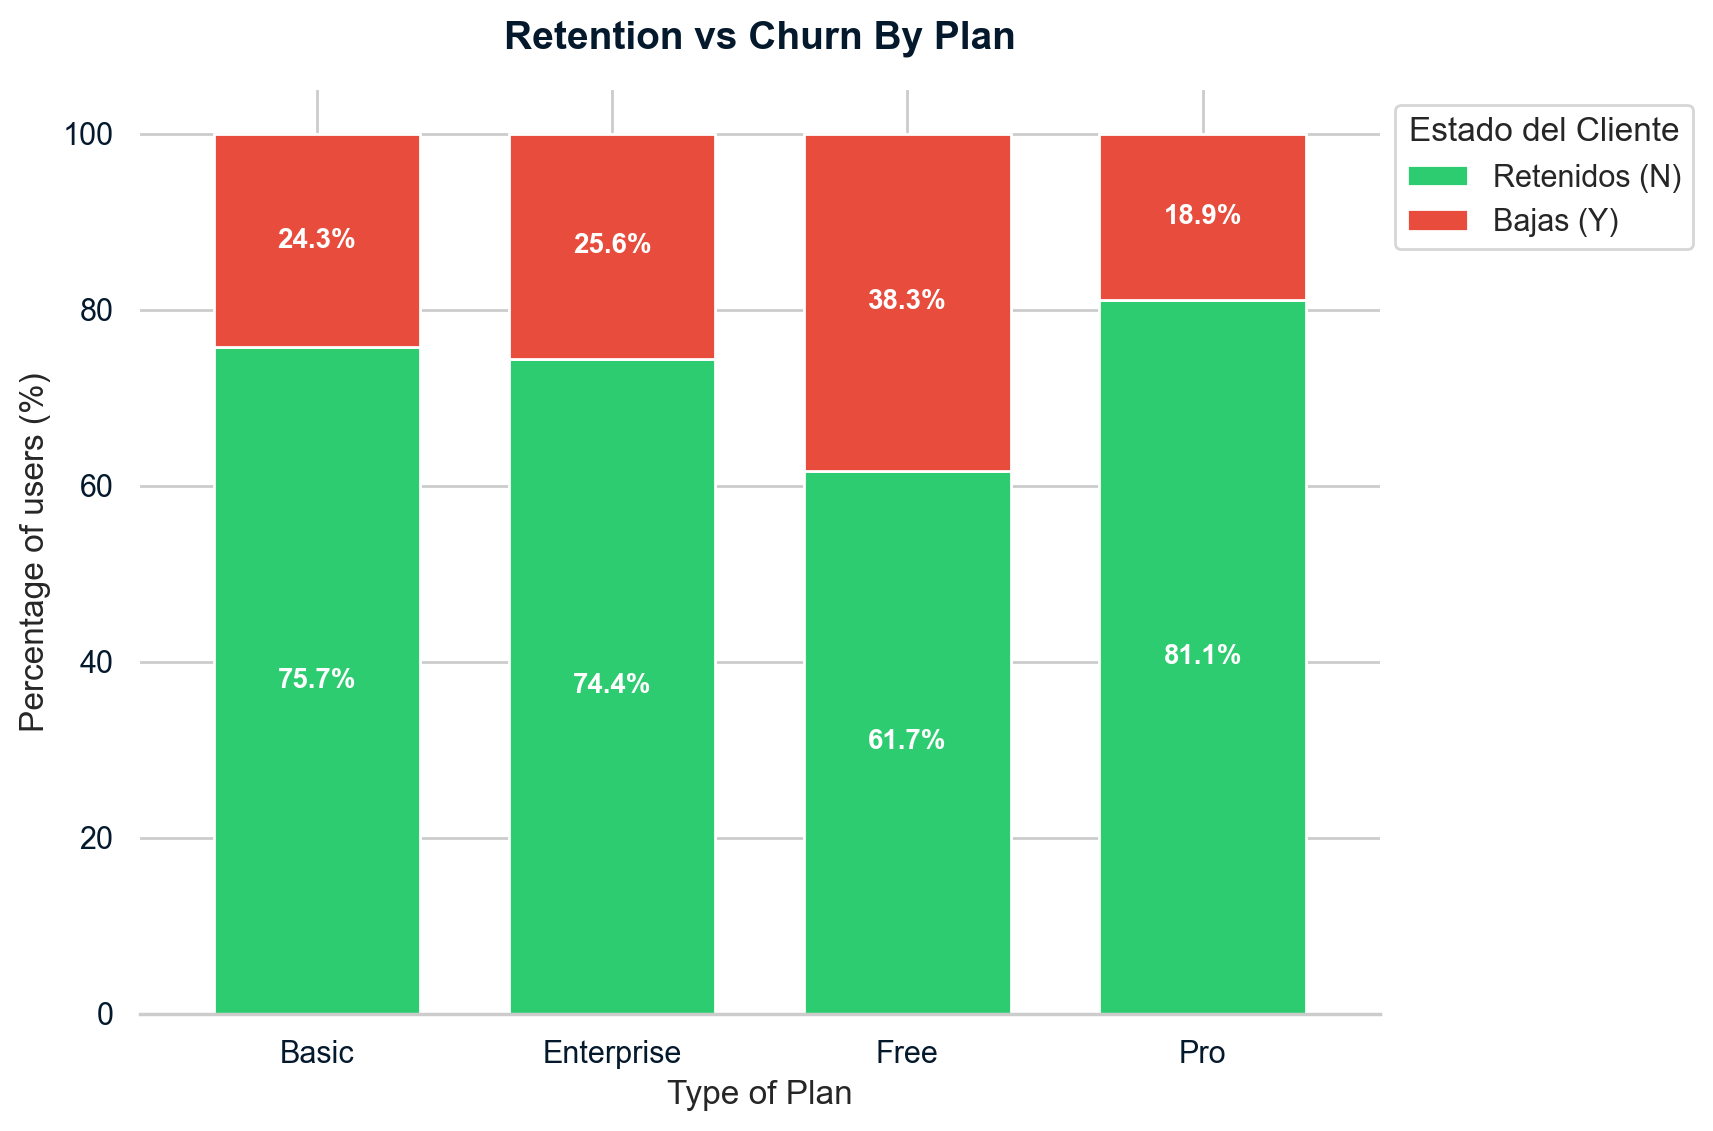

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating crosstab
tabla_cruzada = pd.crosstab(df_account_clean['plan'], df_account_clean['churn_status'])

# Turning into percentage
tabla_porcentajes = tabla_cruzada.div(tabla_cruzada.sum(axis=1), axis=0) * 100

# Style
sns.set_theme(style="whitegrid")
colores = ['#2ecc71', '#e74c3c'] # Green for stayed users (N), Red for churned  (Y)

# Barplot
ax = tabla_porcentajes.plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 6), 
    color=colores,
    width=0.7
)

# Labels
for c in ax.containers:
    
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

# Titles
plt.title('Retention vs Churn By Plan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Type of Plan', fontsize=12)
plt.ylabel('Percentage of users (%)', fontsize=12)

# Ajusting labels
plt.xticks(rotation=0)

# Moving the leyend to the side
plt.legend(title='Estado del Cliente', labels=['Retenidos (N)', 'Bajas (Y)'], 
           loc='upper left', bbox_to_anchor=(1, 1))

sns.despine(left=True)

plt.show()

**Impact of App Usage on Retention:**
Next, we evaluate whether underutilization of the app correlates with higher churn rates. This chart displays the average user activity segmented by plan type, comparing the engagement levels of active users versus those who cancelled their subscriptions.

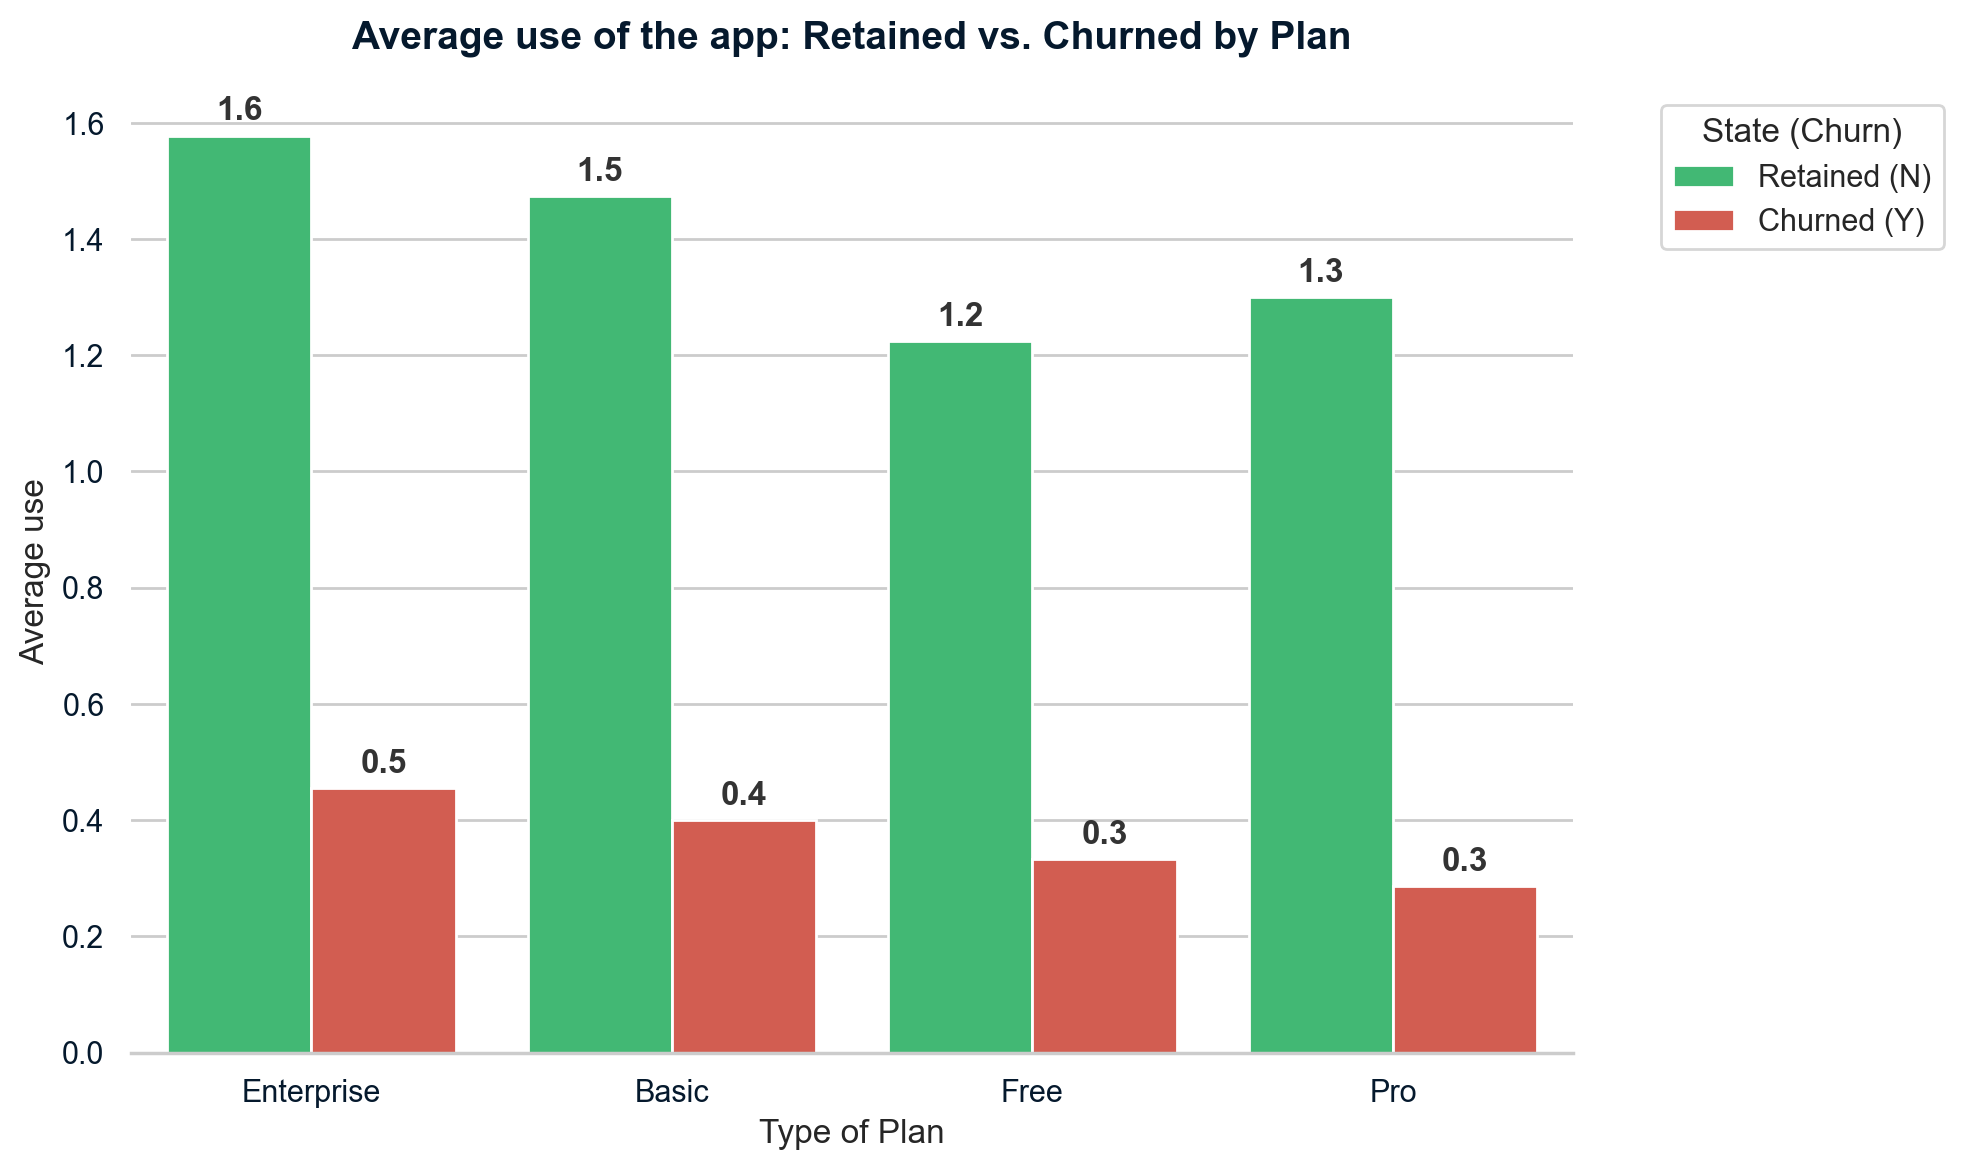

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Changing customer_id to INT
df_account_clean['customer_id'] = df_account_clean['customer_id'].astype(str).str.replace('C', '').astype(int)
df_activity_clean['user_id'] = df_activity_clean['user_id'].astype(int)

# Preparing data
actividad_resumen = df_activity_clean.groupby('user_id').size().reset_index(name='total_events')

# Merge
df_uso_churn = pd.merge(
    df_account_clean, 
    actividad_resumen, 
    left_on='customer_id', 
    right_on='user_id', 
    how='left'
)

# Filling nulls
df_uso_churn['total_events'] = df_uso_churn['total_events'].fillna(0)



df_uso_churn['churn_status'] = df_uso_churn['churn_status'].fillna('N')
# Luego, traducimos las letras a los textos que busca la gráfica
df_uso_churn['churn_status'] = df_uso_churn['churn_status'].replace({
    'N': 'Retained (N)', 
    'Y': 'Churned (Y)'
})


# --- PASO 3: CREAR EL GRÁFICO ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='plan', 
    y='total_events', 
    hue='churn_status', 
    data=df_uso_churn,
    hue_order=['Retained (N)', 'Churned (Y)'], 
    palette={'Retained (N)': '#2ecc71', 'Churned (Y)': '#e74c3c'}, 
    errorbar=None 
)

# Agregamos los números exactos sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontweight='bold', color='#333333')

# Títulos y limpieza visual
plt.title('Average use of the app: Retained vs. Churned by Plan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Type of Plan', fontsize=12)
plt.ylabel('Average use', fontsize=12)

# Mover la leyenda afuera
plt.legend(title='State (Churn)', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine(left=True)
plt.tight_layout()
plt.show()

**Interpretation:**
The data validates our assumption: a lack of engagement directly drives churn. Since low-activity users are the most likely to cancel their subscriptions, the immediate recommendation is to launch re-engagement campaigns (such as push notifications or email workflows) to increase active usage and demonstrate the app's value.

**Resolution time vs topic of the problem:**
To further optimize our support operations, we investigated whether specific ticket topics are inherently more complex and take significantly longer to resolve than others.

<AxesSubplot: xlabel='topic', ylabel='resolution_time_hours'>

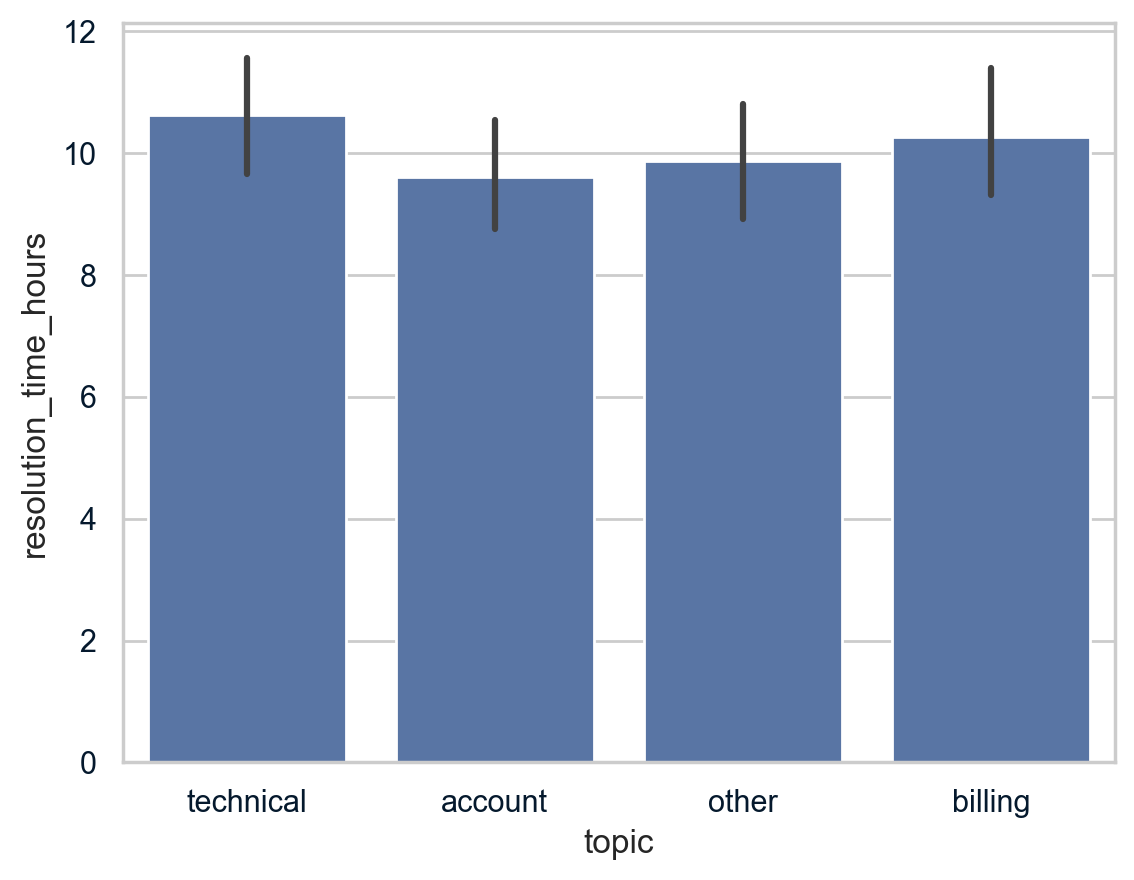

In [18]:
sns.barplot(x='topic', y='resolution_time_hours', data=df_support_clean)


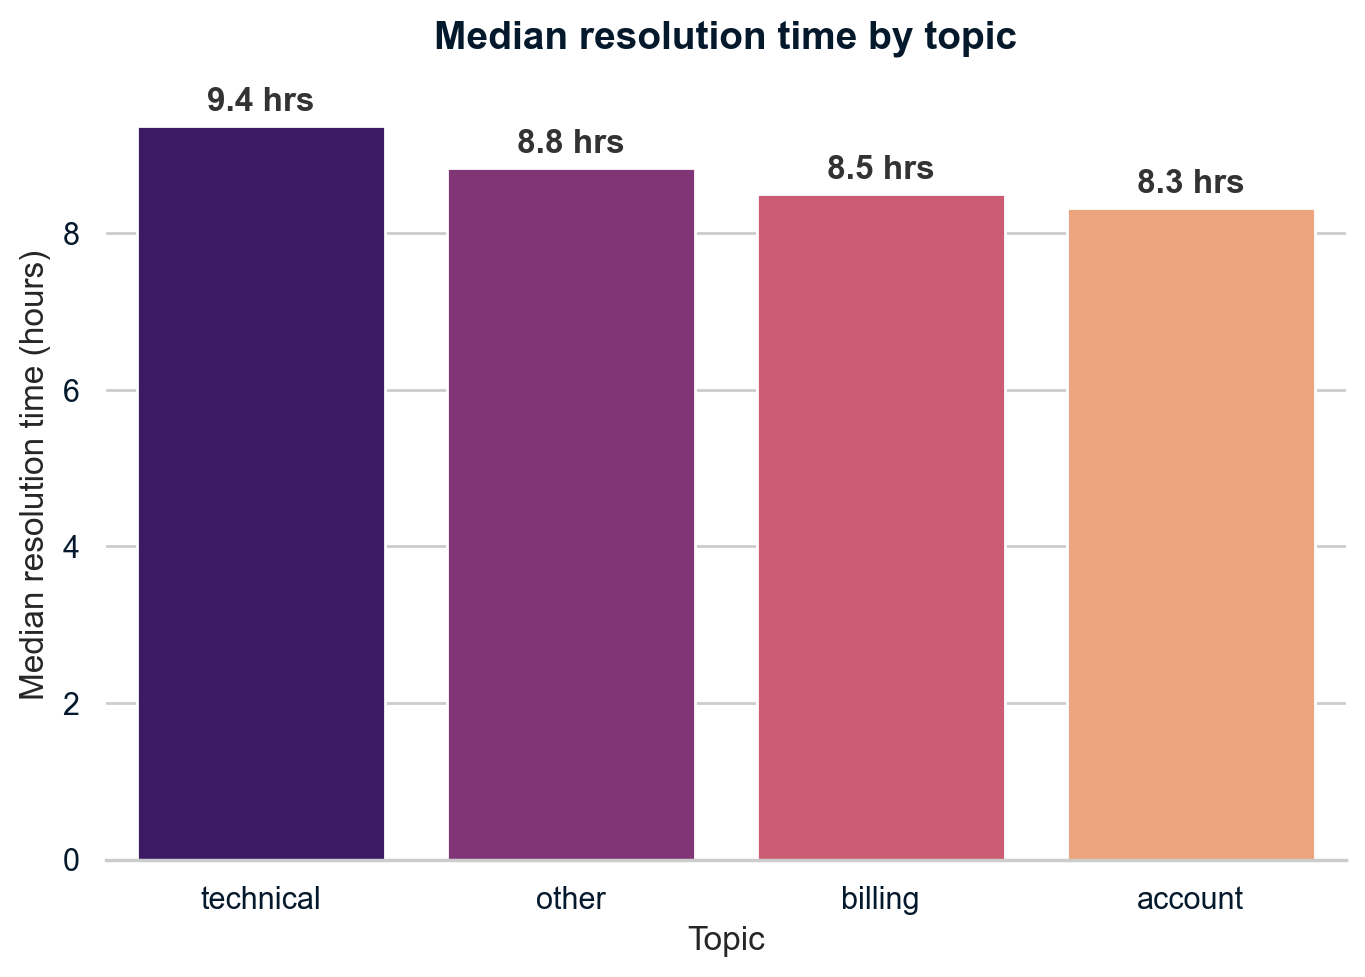

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Order Descending
orden_topics = df_support_clean.groupby('topic')['resolution_time_hours'].median().sort_values(ascending=False).index

ax = sns.barplot(
    x='topic', 
    y='resolution_time_hours', 
    data=df_support_clean,
    estimator=np.median, 
    order=orden_topics,
    palette='magma',
    errorbar=None 
)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f hrs', padding=3, fontweight='bold', color='#333')

plt.title('Median resolution time by topic', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Median resolution time (hours)', fontsize=12)

sns.despine(left=True)
plt.show()

**Interpretation:**
According to the mean and median resolution times, there is no significant difference across the different topics. However, since all categories take over 8 hours to resolve on average, this is a clear area for improvement.

**Correlation Between Resolution Time and Churn:**
For our final analysis, we need to investigate whether prolonged support resolution times directly influence a customer's decision to cancel their subscription.

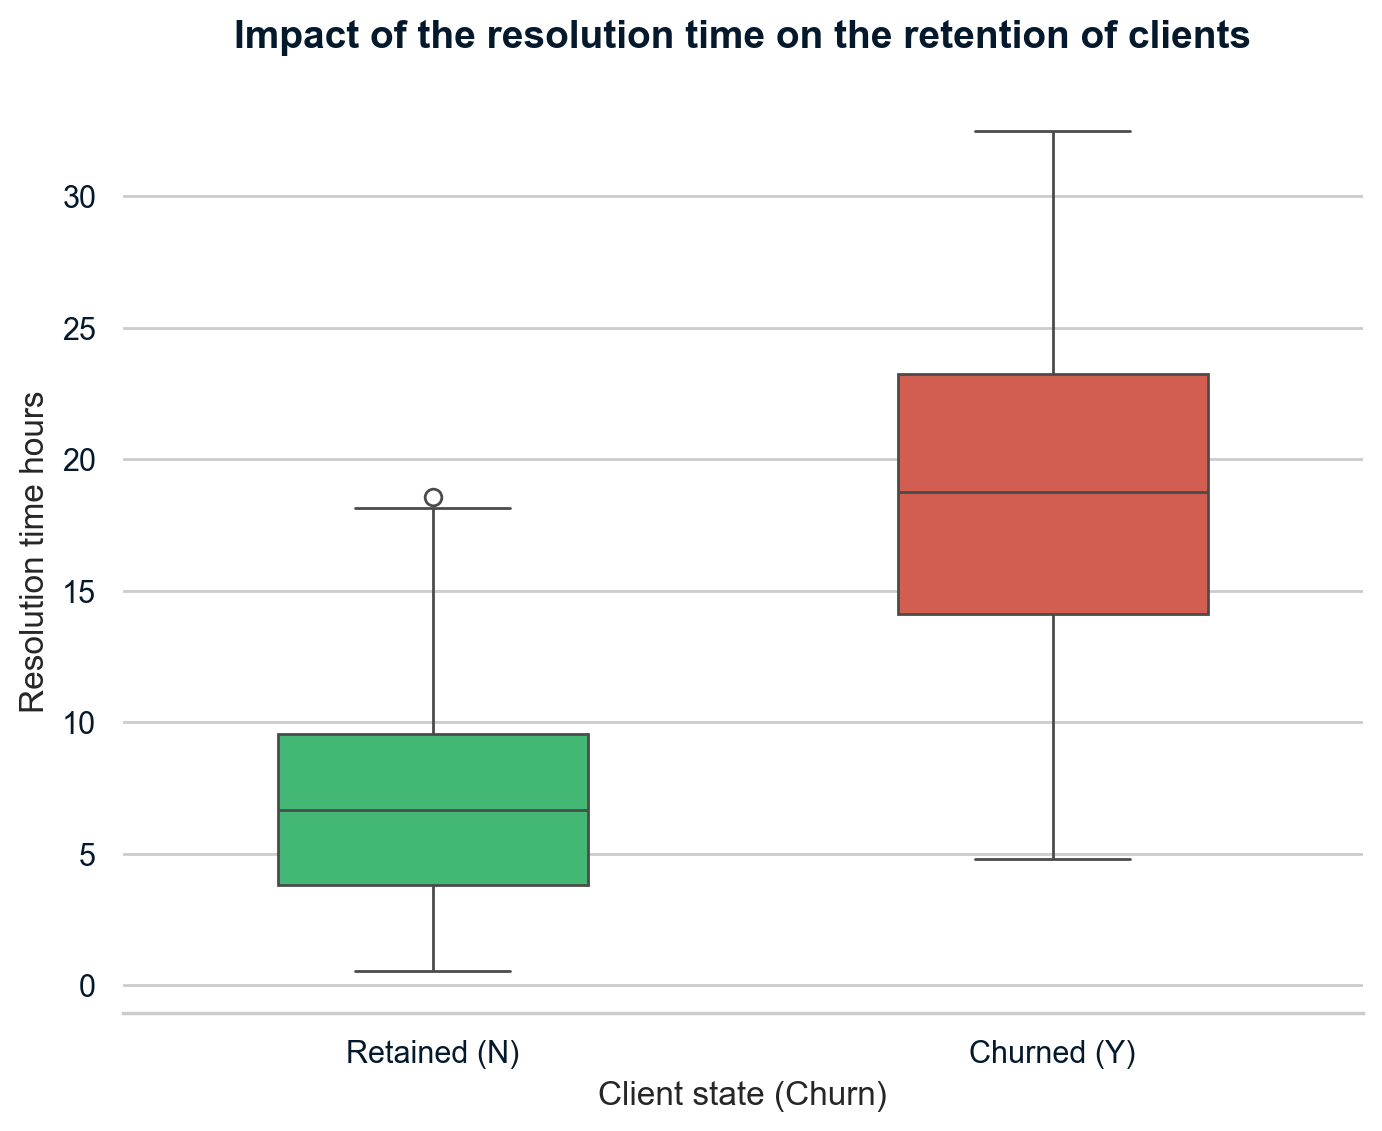

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df_account_clean['churn_status'] = df_account_clean['churn_status'].fillna('N') 

# Rename
df_account_clean['churn_status'] = df_account_clean['churn_status'].replace({
    'N': 'Retained (N)', 
    'Y': 'Churned (Y)'
})

# Merge
customer_support_churn = pd.merge(
    df_account_clean, 
    df_support_clean, 
    left_on='customer_id', 
    right_on='user_id', 
    how='inner'
)

# Boxplot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))


sns.boxplot(
    x='churn_status', 
    y='resolution_time_hours', 
    data=customer_support_churn,
    order=['Retained (N)', 'Churned (Y)'], # Le decimos en qué orden dibujarlos
    palette={'Retained (N)': '#2ecc71', 'Churned (Y)': '#e74c3c'}, 
    width=0.5
)

# Títulos y limpieza visual (Ya NO usamos plt.xticks)
plt.title('Impact of the resolution time on the retention of clients', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Client state (Churn)', fontsize=12)
plt.ylabel('Resolution time hours', fontsize=12)

sns.despine(left=True)
plt.show()


**Interpretation:**
This is arguably the most critical insight of the analysis. The data clearly demonstrates a direct relationship: users who experience prolonged support resolution times are significantly more likely to cancel their subscriptions. In short, slow customer service is a primary driver of churn.

**Conclusions:**
-High Churn Baseline: The overall churn rate stands at 27.2%. Given high Customer Acquisition Costs (CAC), mitigating this churn is a critical business imperative.

-Balanced User Distribution: The user base is evenly distributed across subscription tiers, with the 'Basic' plan being the most adopted.

-Sunk-Cost Effect: The 'Free' tier exhibits the highest cancellation rate (38.3%). The lack of financial commitment significantly lowers the barrier to exit.

-Engagement Drives Retention: Data confirms that poor app engagement is a leading indicator of churn. Across all subscription plans, users who eventually cancelled demonstrated drastically lower interaction rates.

-Support Bottlenecks: Analysis of the customer service data reveals a systemic bottleneck. Resolution times exceed 8 hours on average, regardless of the ticket topic.

-Primary KPI (Resolution Time): Prolonged support waits are the primary driver of churn. Retained users experienced median wait times of ~6.6 hours, whereas churned users suffered delays of nearly 19 hours. Consequently, optimizing the Average Resolution Time (ART) is our recommended metric to monitor.

**Definition of a metric for the business to monitor**

**Metric:** The primary metric the business must monitor is the Median Resolution Time (MRT) for customer support tickets.

**How should the business monitor it?**
The support operations team should implement a real-time tracking dashboard to monitor the MRT daily, segmented by support channel (phone, chat, email). Furthermore, the business should establish a strict Service Level Agreement (SLA) of 7 hours, as our data shows that retained users typically have their issues resolved within this timeframe. Automated alerts should be triggered for the support team whenever an open ticket approaches this 7-hour threshold.

**Estimated Initial Value:**
Based on our cleaned historical data, the current baseline Overall MRT is 8.9 hours. However, for users who ultimately churned, this initial value skyrockets to 18.7 hours. The immediate goal is to bring the global average safely below the 7-hour mark.

**Final recommendations:**
To mitigate churn and improve the overall Customer Lifetime Value (CLV), the business should immediately undertake the following actions:

**Overhaul Support Operations :** Support delays are actively destroying retention. The company must optimize its support queue to ensure all tickets are resolved within 7 hours. We recommend investigating the tickets that enter without a specific channel ("-") as they tend to get lost in the system, and allocating more staff to handle technical and billing issues faster.

**Launch Re-engagement Campaigns:** Since low app usage is a leading indicator of cancellation, the marketing team should implement automated push notifications and email workflows. These should target users who haven't logged an event in their first few days, encouraging them to open the app and discover its value.

**Force the "Aha!" Moment during Onboarding:** Our data indicates that retained users actively log workouts (track_workout). The product team should redesign the app's onboarding process to guide (or require) new users, especially those on the Free tier, to track their first workout immediately. This will create a habit and increase the perceived value of the app before they consider cancelling.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation